# 🖐️ Hand Gesture Recognition – Full Pipeline + MLflow Tracking

**Dataset:** HaGRID (Hand Gesture Recognition Image Dataset) – landmark CSV  
**Goal:** Classify 18 hand gestures from 21 MediaPipe 3-D landmarks per sample  
**Tracking:** MLflow (local `mlruns/` folder)  
**Branch:** `research`

---
### Pipeline
1. Environment Setup  
2. Imports  
3. Data Loading  
4. Data Visualization  
5. Data Preprocessing  
6. MLflow Utility Setup  
7. Model Training + MLflow Logging  
8. Model Evaluation + Comparison  
9. Model Registry  


## Environment Setup

In [1]:
# ── Install dependencies ────────────────────────────────────────────────
import subprocess, sys

packages = [
    "mlflow",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "ipykernel",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])
print("✅ All packages installed")

# ── Save requirements.txt ───────────────────────────────────────────────
reqs = "\n".join([
    "mlflow>=2.13",
    "scikit-learn>=1.4",
    "pandas>=2.0",
    "numpy>=1.26",
    "matplotlib>=3.8",
    "seaborn>=0.13",
    "ipykernel",
])

with open("requirements.txt", "w") as f:
    f.write(reqs)

print("✅ requirements.txt saved")


✅ All packages installed
✅ requirements.txt saved


## GitHub Research Branch

In [2]:
import subprocess

# ── FILL THESE IN ──────────────────────────────────────────────────────────
GITHUB_USER  = "YOUR_GITHUB_USERNAME"
GITHUB_EMAIL = "YOUR_GITHUB_EMAIL"
REPO_URL     = "https://github.com/YOUR_GITHUB_USERNAME/YOUR_REPO.git"
# ───────────────────────────────────────────────────────────────────────────

def git(cmd: str):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"⚠️  {result.stderr.strip()}")
    else:
        print(f"✅ {result.stdout.strip() or cmd}")

git(f'git config user.name  "{GITHUB_USER}"')
git(f'git config user.email "{GITHUB_EMAIL}"')

# Create / switch to research branch
git("git init")
git("git remote remove origin 2>/dev/null; git remote add origin " + REPO_URL)
git("git checkout -B research")

print("\n🚀 Ready – you are on branch 'research'")


✅ git config user.name  "YOUR_GITHUB_USERNAME"
✅ git config user.email "YOUR_GITHUB_EMAIL"
✅ Reinitialized existing Git repository in D:/ITI/ML 1_project/.git/
⚠️  The system cannot find the path specified.
✅ M	mlflow_utils.py
D	mlruns/0/meta.yaml
Your branch is up to date with 'origin/research'.

🚀 Ready – you are on branch 'research'


## Imports

In [3]:
# Standard
import os, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
print("✅ Imports OK")


✅ Imports OK


## Data Loading

In [4]:
# ── UPDATE THIS PATH ───────────────────────────────────────────────────────
DATA_PATH = "hand_landmarks_data.csv"
# ──────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_PATH)

print(f"Shape  : {df.shape}")
print(f"Classes: {df['label'].nunique()}")
df.head()


Shape  : (25675, 64)
Classes: 18


,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


## Data Visualization

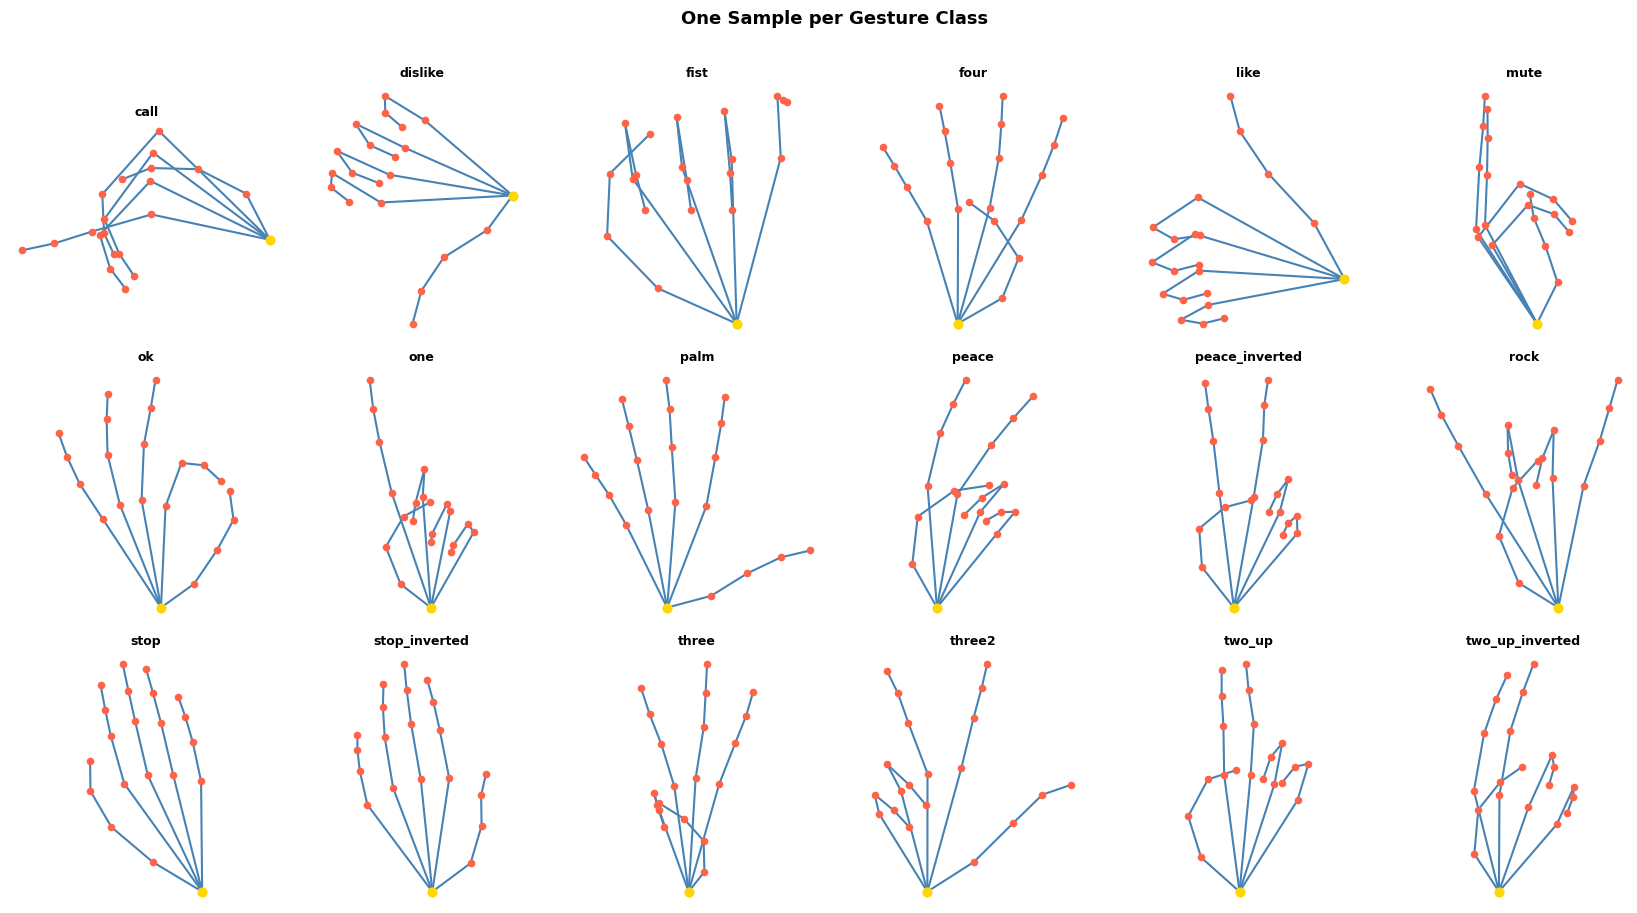

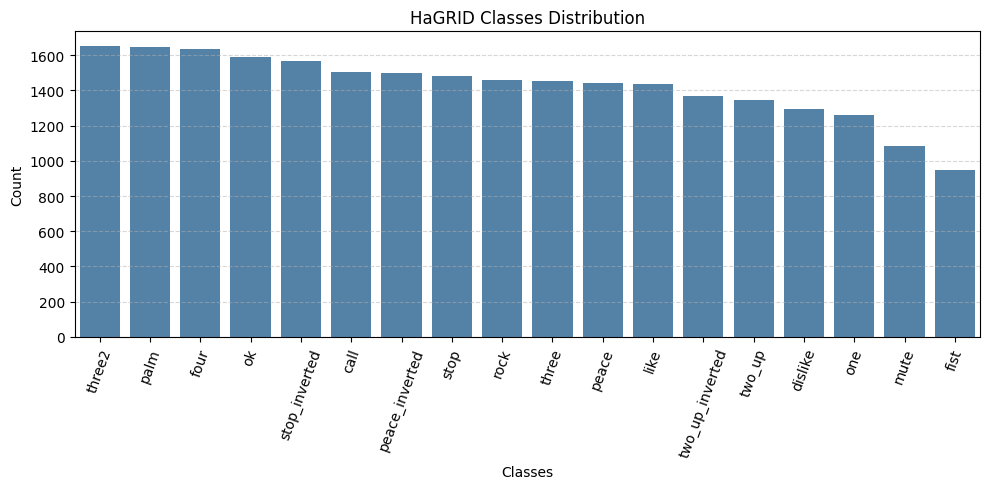

In [5]:
# ── MediaPipe landmark connections ────────────────────────────────────────
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
]

def plot_landmark(data):
    labels = sorted(data['label'].unique())
    cols = 6
    rows = (len(labels) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.8, rows * 3))
    axes = axes.flatten()

    for idx, label in enumerate(labels):
        ax = axes[idx]
        sample = data[data['label'] == label].iloc[0]
        xs = [sample[f'x{i}'] for i in range(1, 22)]
        ys = [sample[f'y{i}'] for i in range(1, 22)]

        for s, e in HAND_CONNECTIONS:
            ax.plot([xs[s], xs[e]], [ys[s], ys[e]], color='steelblue', lw=1.5, zorder=1)

        ax.scatter(xs, ys, c='tomato', s=20, zorder=2)
        ax.scatter([xs[0]], [ys[0]], c='gold', s=40, zorder=3)
        ax.set_title(label, fontsize=9, fontweight='bold')
        ax.invert_yaxis(); ax.set_aspect('equal'); ax.axis('off')

    for j in range(len(labels), len(axes)):
        axes[j].axis('off')

    fig.suptitle('One Sample per Gesture Class', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

plot_landmark(df)

# ── Class distribution ────────────────────────────────────────────────────
count_df = df['label'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=count_df.index, y=count_df.values, color='steelblue')
plt.title('HaGRID Classes Distribution')
plt.xlabel('Classes'); plt.ylabel('Count')
plt.xticks(rotation=70); plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


## Data Investigation

In [6]:
print("── Null values ──")
print(df.isna().sum().to_string())

print("\n── Duplicates ──")
print(df.duplicated().sum(), "duplicate rows")

print("\n── Descriptive stats ──")
df.describe()


── Null values ──
x1       0
y1       0
z1       0
x2       0
y2       0
z2       0
x3       0
y3       0
z3       0
x4       0
y4       0
z4       0
x5       0
y5       0
z5       0
x6       0
y6       0
z6       0
x7       0
y7       0
z7       0
x8       0
y8       0
z8       0
x9       0
y9       0
z9       0
x10      0
y10      0
z10      0
x11      0
y11      0
z11      0
x12      0
y12      0
z12      0
x13      0
y13      0
z13      0
x14      0
y14      0
z14      0
x15      0
y15      0
z15      0
x16      0
y16      0
z16      0
x17      0
y17      0
z17      0
x18      0
y18      0
z18      0
x19      0
y19      0
z19      0
x20      0
y20      0
z20      0
x21      0
y21      0
z21      0
label    0

── Duplicates ──
0 duplicate rows

── Descriptive stats ──


,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029986e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243216e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887403,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497277e-07,199.979530,247.113892,-0.008737,200.092758,235.776978,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485229,-0.025269
75%,266.428482,304.991663,2.989988e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007134,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556020,781.674469,1.876254e-06,606.232386,751.869416,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788521,760.554894,0.118668


## Normalisation + Label Encoding + Split

Formula:  
`xi_norm = (xi − x_wrist) / x_mid_fingertip`

Split: **60 % train · 20 % val · 20 % test**, `random_state=100`

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ── Normalise ─────────────────────────────────────────────────────────────
clean_data = df.copy()
x_wrist, y_wrist = clean_data['x1'], clean_data['y1']
x_mid,   y_mid   = clean_data['x13'], clean_data['y13']

for i in range(1, 22):
    clean_data[f'x{i}'] = (clean_data[f'x{i}'] - x_wrist) / x_mid
    clean_data[f'y{i}'] = (clean_data[f'y{i}'] - y_wrist) / y_mid

# ── Label encode ──────────────────────────────────────────────────────────
le = LabelEncoder()
clean_data['label'] = le.fit_transform(clean_data['label'])

# ── Save processed CSV ────────────────────────────────────────────────────
PROCESSED_PATH = "processed_hand_landmarks_data.csv"
clean_data.to_csv(PROCESSED_PATH, index=False)
print(f"✅ Saved {PROCESSED_PATH}")

# ── Split ─────────────────────────────────────────────────────────────────
data = pd.read_csv(PROCESSED_PATH)
features = data.drop('label', axis=1)
labels   = data['label']

x_train, x_vt, y_train, y_vt = train_test_split(features, labels, test_size=0.4, random_state=100)
x_val,   x_test, y_val, y_test = train_test_split(x_vt,    y_vt,  test_size=0.5, random_state=100)

print(f"Train : {len(x_train):,}  |  Val : {len(x_val):,}  |  Test : {len(x_test):,}")


✅ Saved processed_hand_landmarks_data.csv
Train : 15,405  |  Val : 5,135  |  Test : 5,135


## MLflow Utility Import + Experiment Setup

In [9]:
# ── make sure mlflow_utils.py is next to this notebook ────────────────────
import importlib, sys, os

# reload if already imported (helpful during dev)
if "mlflow_utils" in sys.modules:
    importlib.reload(sys.modules["mlflow_utils"])

from mlflow_utils import (
    setup_experiment,
    log_dataset_info,
    log_split_info,
    log_model_params,
    log_metrics,
    log_figure,
    log_model,
    register_model,
    run_experiment,
)
import mlflow

EXP_ID = setup_experiment("hand-gesture-recognition")
print(f"\n✅ MLflow experiment ready  (id={EXP_ID})")
print("   Run: mlflow ui   →  open http://127.0.0.1:5000 in your browser")


2026/02/28 23:50:00 INFO mlflow.tracking.fluent: Experiment with name 'hand-gesture-recognition' does not exist. Creating a new experiment.


[MLflow] Tracking URI : mlruns
[MLflow] Experiment   : 'hand-gesture-recognition'  (id=736677134348880829)

✅ MLflow experiment ready  (id=736677134348880829)
   Run: mlflow ui   →  open http://127.0.0.1:5000 in your browser


## Shared Metrics Helper

In [11]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(model, x, y):
    y_pred = model.predict(x)
    return {
        "accuracy"  : accuracy_score(y, y_pred),
        "f1_macro"  : f1_score(y, y_pred, average="macro"),
        "precision" : precision_score(y, y_pred, average="macro"),
        "recall"    : recall_score(y, y_pred, average="macro"),
    }

print("✅ compute_metrics() ready")


✅ compute_metrics() ready


## Logistic Regression + MLflow Run

> **Commit after this cell:**  
> `git add mlruns/ && git commit -m 'experiment: logistic-regression run' && git push origin research`


In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(x_train, y_train)

lr_run_id = run_experiment(
    run_name      = "logistic-regression-baseline",
    model         = lr_model,
    model_label   = "LogisticRegression",
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    x_test=x_test,   y_test=y_test,
    df_raw=df,       df_processed=clean_data,
    metrics_fn    = compute_metrics,
)

print(f"\n✅ LR run_id: {lr_run_id}")
print("   Val metrics:", compute_metrics(lr_model, x_val, y_val))


[MLflow] Dataset artifact logged: processed_hand_landmarks_data.csv


2026/02/28 23:50:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 23:50:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] Model logged → runs:/00ad1150c7134d4eb16c5229ce766f6a/model
[MLflow] Run 'logistic-regression-baseline' finished  run_id=00ad1150c7134d4eb16c5229ce766f6a

✅ LR run_id: 00ad1150c7134d4eb16c5229ce766f6a
   Val metrics: {'accuracy': 0.7914313534566699, 'f1_macro': 0.7960525131978028, 'precision': 0.7967079806812123, 'recall': 0.800084357488951}


## Decision Tree + MLflow Run

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(x_train, y_train)

dt_run_id = run_experiment(
    run_name      = "decision-tree-baseline",
    model         = dt_model,
    model_label   = "DecisionTree",
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    x_test=x_test,   y_test=y_test,
    df_raw=df,       df_processed=clean_data,
    metrics_fn    = compute_metrics,
)

print(f"\n✅ DT run_id: {dt_run_id}")
print("   Val metrics:", compute_metrics(dt_model, x_val, y_val))


[MLflow] Dataset artifact logged: processed_hand_landmarks_data.csv


2026/02/28 23:52:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 23:52:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] Model logged → runs:/dd2da08f214e47ddaf6628cf578de747/model
[MLflow] Run 'decision-tree-baseline' finished  run_id=dd2da08f214e47ddaf6628cf578de747

✅ DT run_id: dd2da08f214e47ddaf6628cf578de747
   Val metrics: {'accuracy': 0.8529698149951315, 'f1_macro': 0.8555618213711825, 'precision': 0.8565212077711077, 'recall': 0.8550424412981218}


## SVM + MLflow Run

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(class_weight='balanced', kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(x_train, y_train)

svm_run_id = run_experiment(
    run_name      = "svm-rbf-baseline",
    model         = svm_model,
    model_label   = "SVM-RBF",
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    x_test=x_test,   y_test=y_test,
    df_raw=df,       df_processed=clean_data,
    metrics_fn    = compute_metrics,
)

print(f"\n✅ SVM run_id: {svm_run_id}")
print("   Val metrics:", compute_metrics(svm_model, x_val, y_val))


[MLflow] Dataset artifact logged: processed_hand_landmarks_data.csv


2026/02/28 23:53:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 23:53:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] Model logged → runs:/b6f4523d779246d9bf997357e9ab5de4/model
[MLflow] Run 'svm-rbf-baseline' finished  run_id=b6f4523d779246d9bf997357e9ab5de4

✅ SVM run_id: b6f4523d779246d9bf997357e9ab5de4
   Val metrics: {'accuracy': 0.8229795520934762, 'f1_macro': 0.8296507056023146, 'precision': 0.8466162132479705, 'recall': 0.8300955967704441}


## Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators  = 100,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1,
)
rf_model.fit(x_train, y_train)

rf_run_id = run_experiment(
    run_name      = "random-forest-n100",
    model         = rf_model,
    model_label   = "RandomForest",
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    x_test=x_test,   y_test=y_test,
    df_raw=df,       df_processed=clean_data,
    metrics_fn    = compute_metrics,
)

print(f"\n✅ RF run_id: {rf_run_id}")
print("   Val metrics:", compute_metrics(rf_model, x_val, y_val))


[MLflow] Dataset artifact logged: processed_hand_landmarks_data.csv


2026/03/01 00:05:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 00:05:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] Model logged → runs:/dbaf1ae2332746958db0ccd48b1ba718/model
[MLflow] Run 'random-forest-n100' finished  run_id=dbaf1ae2332746958db0ccd48b1ba718

✅ RF run_id: dbaf1ae2332746958db0ccd48b1ba718
   Val metrics: {'accuracy': 0.9259980525803311, 'f1_macro': 0.9276450200842733, 'precision': 0.9282532961112923, 'recall': 0.9273750542007435}


## Model Comparison

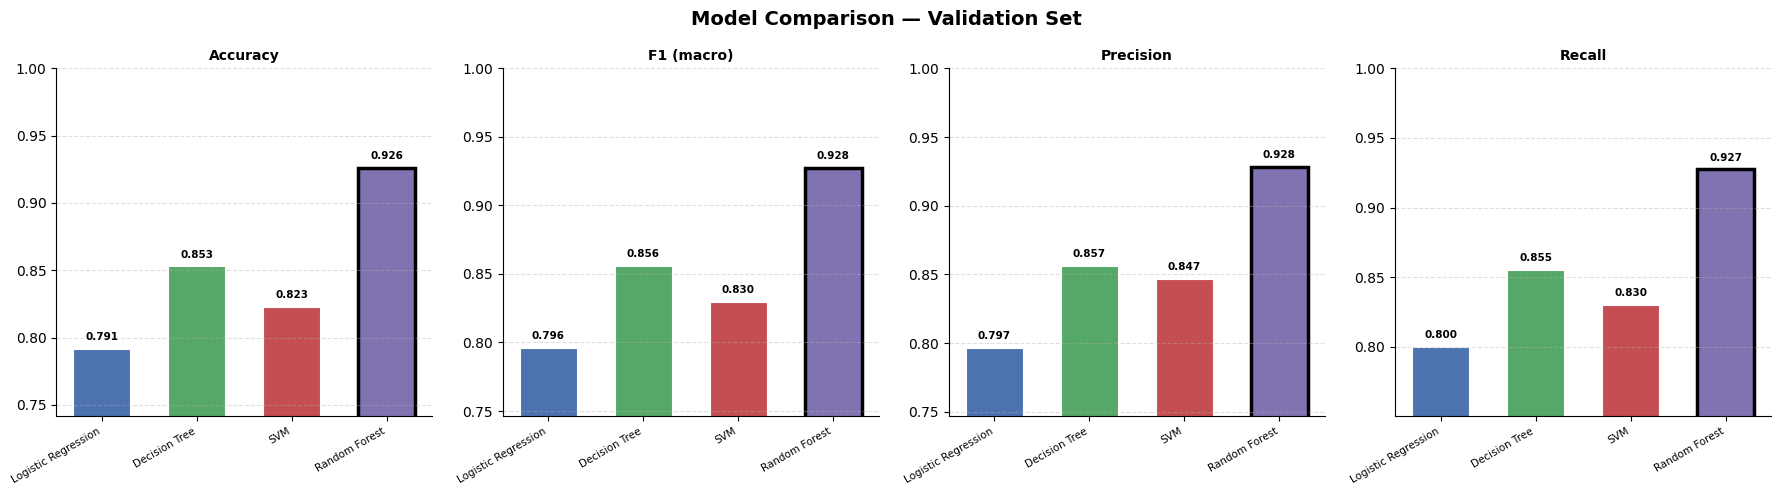

[MLflow] Figure logged: model_comparison.png
[MLflow] Figure logged: model_comparison.png
[MLflow] Figure logged: model_comparison.png
[MLflow] Figure logged: model_comparison.png

✅ Comparison chart logged to all runs and saved to screenshots/


In [16]:
models_dict = {
    "Logistic\nRegression": lr_model,
    "Decision\nTree":       dt_model,
    "SVM":                   svm_model,
    "Random\nForest":       rf_model,
}

metric_keys  = ["accuracy", "f1_macro", "precision", "recall"]
metric_labels = ["Accuracy", "F1 (macro)", "Precision", "Recall"]
colors       = ['#4C72B0','#55A868','#C44E52','#8172B2']

results = {}
for name, mdl in models_dict.items():
    results[name] = compute_metrics(mdl, x_val, y_val)

# ── Draw ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Model Comparison — Validation Set', fontsize=14, fontweight='bold')

for ax, mkey, mlabel in zip(axes, metric_keys, metric_labels):
    model_names = list(models_dict.keys())
    values      = [results[n][mkey] for n in model_names]
    bars = ax.bar(range(len(model_names)), values, color=colors,
                  width=0.6, edgecolor='white', linewidth=0.8)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

    best_idx = int(np.argmax(values))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)

    short = [n.replace('\n', ' ') for n in model_names]
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(short, fontsize=7.5, rotation=30, ha='right')
    ax.set_title(mlabel, fontsize=10, fontweight='bold')
    ax.set_ylim(max(0, min(values) - 0.05), min(1.0, max(values) + 0.12))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# save locally for README + screenshots folder
os.makedirs("screenshots", exist_ok=True)
fig.savefig("screenshots/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Log the chart to every run ────────────────────────────────────────────
import mlflow
for run_id in [lr_run_id, dt_run_id, svm_run_id, rf_run_id]:
    with mlflow.start_run(run_id=run_id):
        log_figure(fig, "model_comparison.png", artifact_subdir="plots")

print("\n✅ Comparison chart logged to all runs and saved to screenshots/")


## Confusion Matrix (best model)

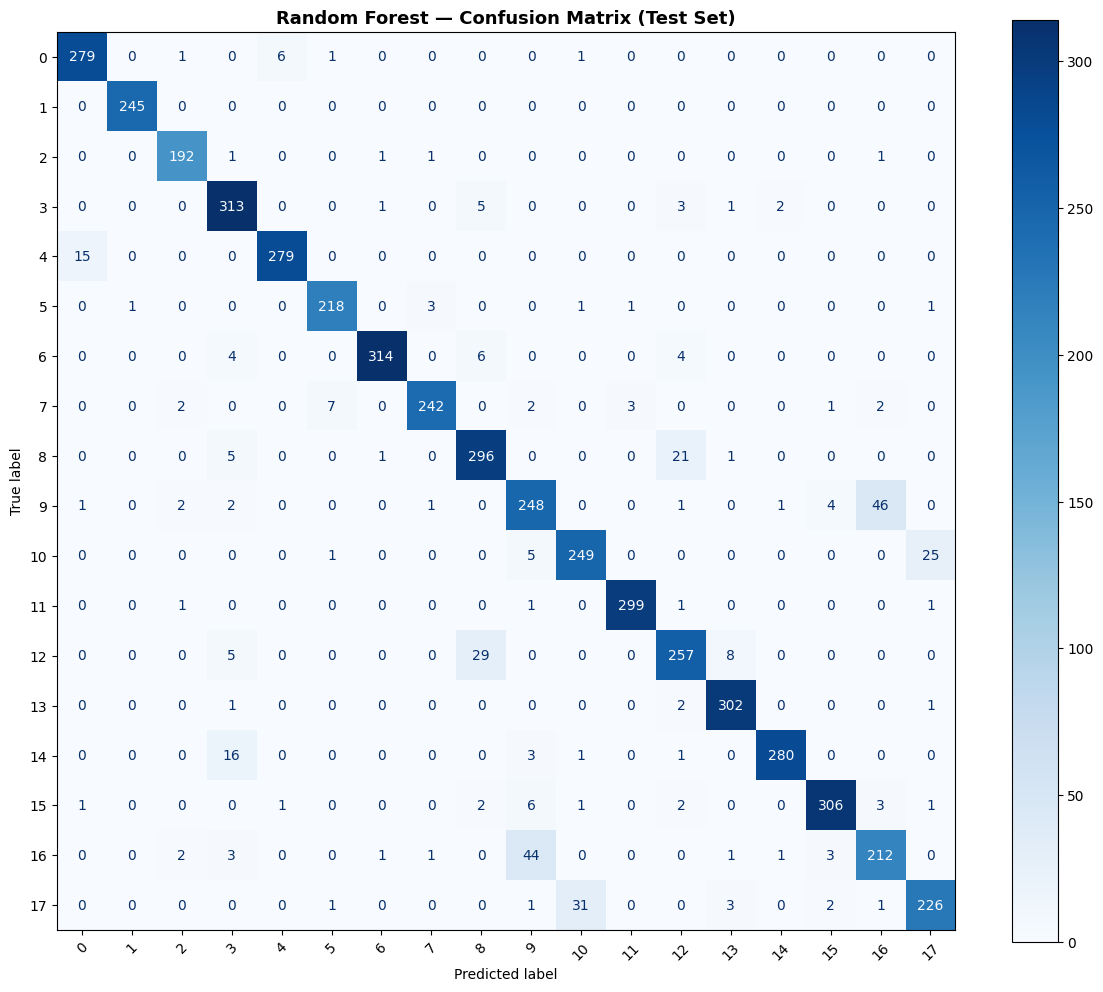

[MLflow] Figure logged: rf_confusion_matrix.png
✅ Confusion matrix logged


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred_rf = rf_model.predict(x_test)

fig_cm, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Random Forest — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig_cm.savefig("screenshots/rf_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# log to the RF run
with mlflow.start_run(run_id=rf_run_id):
    log_figure(fig_cm, "rf_confusion_matrix.png", artifact_subdir="plots")

print("✅ Confusion matrix logged")


## Results Table

In [ ]:
print(f"{'Model':<22}  {'Accuracy':>9}  {'F1 macro':>9}  {'Precision':>9}  {'Recall':>9}")
print("─" * 65)

for name, mdl in [("Logistic Regression", lr_model),
                   ("Decision Tree",       dt_model),
                   ("SVM (RBF)",           svm_model),
                   ("Random Forest",       rf_model)]:
    m = compute_metrics(mdl, x_test, y_test)
    marker = " ✅" if name == "Random Forest" else ""
    print(f"{name:<22}  {m['accuracy']:>9.4f}  {m['f1_macro']:>9.4f}  "
          f"{m['precision']:>9.4f}  {m['recall']:>9.4f}{marker}")

print("\n✅ = selected model registered in MLflow Model Registry")


Model                    Accuracy   F1 macro  Precision     Recall
─────────────────────────────────────────────────────────────────
Logistic Regression        0.7938     0.7966     0.7971     0.8002
Decision Tree              0.8504     0.8528     0.8540     0.8525
SVM (RBF)                  0.8210     0.8273     0.8418     0.8263
Random Forest              0.9264     0.9273     0.9280     0.9272 ✅

✅ = selected model registered in MLflow Model Registry


## Register Best Model in MLflow Registry

In [ ]:
mv = register_model(
    run_id        = rf_run_id,
    registry_name = "hagrid-gesture-classifier",
)

print(f"\n🏆 Model registered!")
print(f"   Name   : {mv.name}")
print(f"   Version: {mv.version}")
print(f"   Run ID : {mv.run_id}")
print("\nOpen http://127.0.0.1:5000 → 'Models' tab to see the registry entry.")


Successfully registered model 'hagrid-gesture-classifier'.
2026/03/01 00:07:45 WARNING mlflow.tracking._model_registry.fluent: Run with id dbaf1ae2332746958db0ccd48b1ba718 has no artifacts at artifact path 'model', registering model based on models:/m-0cd2d8072a9d47ac95fcfaa1c46542f4 instead


[MLflow] Registered 'hagrid-gesture-classifier'  version=1  run=dbaf1ae2332746958db0ccd48b1ba718

🏆 Model registered!
   Name   : hagrid-gesture-classifier
   Version: 1
   Run ID : dbaf1ae2332746958db0ccd48b1ba718

Open http://127.0.0.1:5000 → 'Models' tab to see the registry entry.


Created version '1' of model 'hagrid-gesture-classifier'.


In [ ]:
import subprocess

def git(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    out = r.stdout.strip() or r.stderr.strip()
    print(f"$ {cmd}\n  {out}\n")

git("git add .")
git('git commit -m "feat: complete hand-gesture-recognition pipeline with MLflow"')
git("git push origin research")

print("🎉 All done! Your 'research' branch is up to date.")
print("   → Open MLflow UI:  mlflow ui")
print("   → Visit: http://127.0.0.1:5000")


$ git add .

$ git commit -m "feat: complete hand-gesture-recognition pipeline with MLflow"
  [research c869cde] feat: complete hand-gesture-recognition pipeline with MLflow
 3 files changed, 25 insertions(+)
 create mode 100644 mlruns/736677134348880829/models/m-0cd2d8072a9d47ac95fcfaa1c46542f4/tags/mlflow.modelVersions
 create mode 100644 mlruns/models/hagrid-gesture-classifier/meta.yaml
 create mode 100644 mlruns/models/hagrid-gesture-classifier/version-1/meta.yaml

$ git push origin research
  To https://github.com/AlaaSror/ITI_ML_hand_gestures_project.git
   4803a98..c869cde  research -> research

🎉 All done! Your 'research' branch is up to date.
   → Open MLflow UI:  mlflow ui
   → Visit: http://127.0.0.1:5000
